# TP : Analyse en Composantes Principales (ACP)
## Réalisation pas-à-pas avec Python

**Objectif** : Analyser les notes d'étudiants pour identifier des profils types.

---

## Partie 1 : Préparation de l'environnement

In [1]:
# Cellule 1 : Importations nécessaires

# Importer pandas pour les DataFrames
import pandas as pd

# Importer numpy pour les calculs mathématiques
import numpy as np

# Importer matplotlib pour les graphiques
import matplotlib.pyplot as plt

# Importer seaborn pour des graphiques plus esthétiques
import seaborn as sns

# Configuration de l'affichage
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## Partie 2 : Création du jeu de données

In [2]:
# Cellule 2 : Données des étudiants
# Notes de 10 étudiants dans 4 matières
notes = {
    'Maths':    [18, 17, 5,  6,  12, 19, 4,  14, 10, 11],
    'Physique': [19, 16, 6,  5,  11, 18, 5,  13, 10, 12],
    'Arabe':    [8,  9,  16, 17, 10, 6,  18, 9,  12, 11],
    'Anglais':  [7,  8,  15, 18, 11, 5,  19, 8,  11, 10]
}

# Noms des étudiants
etudiants = ['Ahmed', 'Fatima', 'Omar', 'Layla', 'Youssef', 
             'Sara', 'Khaled', 'Nour', 'Mounir', 'Hoda']

# Création du DataFrame
# À COMPLÉTER : Créer un DataFrame avec les notes et les noms des étudiants
df = pd.DataFrame(notes, index=etudiants)

# Affichage
print("Nombre d'étudiants :", df.shape[0])
print("Nombre de matières :", df.shape[1])
print("\nTableau de notes :")
display(df)

Nombre d'étudiants : 10
Nombre de matières : 4

Tableau de notes :


,Maths,Physique,Arabe,Anglais
Ahmed,18,19,8,7
Fatima,17,16,9,8
Omar,5,6,16,15
Layla,6,5,17,18
Youssef,12,11,10,11
Sara,19,18,6,5
Khaled,4,5,18,19
Nour,14,13,9,8
Mounir,10,10,12,11
Hoda,11,12,11,10


## Partie 3 : Centrage et réduction

In [3]:
# Cellule 3 : Statistiques de base
# Calcul des moyennes par matière
# À COMPLÉTER : Calculer la moyenne de chaque colonne
moyennes = df.mean()

# Calcul des écarts-types (population)
# À COMPLÉTER : Calculer l'écart-type avec ddof=0
ecarts_types = df.std(ddof=0)

print("Moyennes par matière :")
print(moyennes)
print("\nÉcarts-types par matière :")
print(ecarts_types)

Moyennes par matière :
Maths       11.6
Physique    11.5
Arabe       11.6
Anglais     11.2
dtype: float64

Écarts-types par matière :
Maths       5.161395
Physique    4.883646
Arabe       3.878144
Anglais     4.467662
dtype: float64


In [8]:
# Cellule 4 : Matrice centrée-réduite Z
# Calcul de la matrice centrée-réduite
# À COMPLÉTER : Appliquer la formule Z = (X - μ) / σ
Z = (df - moyennes) / ecarts_types

# Vérification
print("Vérification - Moyennes de Z (doivent être ~0) :")
print(Z.describe().loc['mean'])
print("\nVérification - Écarts-types de Z (doivent être ~1) :")
print(Z.describe().loc['std'])

print("\nAperçu de Z :")
display(pd.DataFrame(Z, index=etudiants, columns=df.columns).head())

Vérification - Moyennes de Z (doivent être ~0) :
Maths       1.387779e-18
Physique    1.110223e-17
Arabe       1.110223e-16
Anglais     1.720846e-16
Name: mean, dtype: float64

Vérification - Écarts-types de Z (doivent être ~1) :
Maths       1.054093
Physique    1.054093
Arabe       1.054093
Anglais     1.054093
Name: std, dtype: float64

Aperçu de Z :


,Maths,Physique,Arabe,Anglais
Ahmed,1.239975,1.535738,-0.928279,-0.940089
Fatima,1.046229,0.921443,-0.670424,-0.716258
Omar,-1.278724,-1.126208,1.134563,0.850557
Layla,-1.084978,-1.330973,1.392419,1.522049
Youssef,0.077498,-0.102383,-0.412568,-0.044766


## Partie 4 : Matrice de corrélation

In [9]:
# Cellule 5 : Calcul manuel
# Nombre d'individus
n = df.shape[0]

# Calcul de la matrice de corrélation R
# À COMPLÉTER : R = (1/n) × Zᵀ × Z
R = (1 / n) * np.dot(Z.T, Z)

print("Matrice de corrélation R (4x4) :")
print(np.round(R, 3))

Matrice de corrélation R (4x4) :
[[ 1.     0.984 -0.967 -0.951]
 [ 0.984  1.    -0.95  -0.949]
 [-0.967 -0.95   1.     0.986]
 [-0.951 -0.949  0.986  1.   ]]


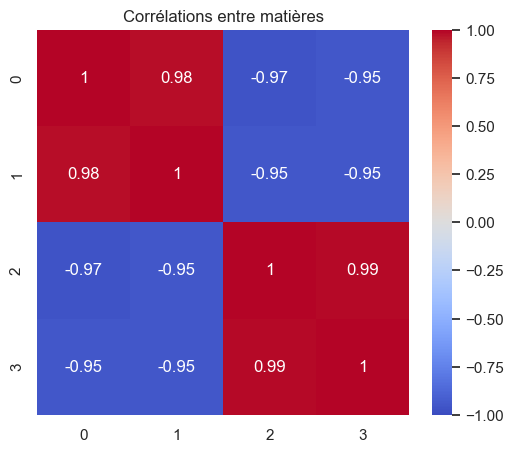

In [10]:
# Cellule 6 : Visualisation
# Heatmap des corrélations
plt.figure(figsize=(6, 5))
# À COMPLÉTER : Créer une heatmap avec seaborn
sns.heatmap(R, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Corrélations entre matières")
plt.show()  # Afficher le graphique

## Partie 5 : Décomposition en valeurs propres

In [11]:
# Cellule 7 : Calcul des valeurs et vecteurs propres
# Décomposition spectrale de la matrice R
# À COMPLÉTER : Calculer valeurs et vecteurs propres
valeurs_propres, vecteurs_propres = np.linalg.eig(R)

print("Valeurs propres brutes :", np.round(valeurs_propres, 3))
print("\nVecteurs propres bruts :")
print(np.round(vecteurs_propres, 3))

Valeurs propres brutes : [3.893 0.078 0.006 0.023]

Vecteurs propres bruts :
[[ 0.501  0.428 -0.531  0.532]
 [ 0.499  0.563  0.401 -0.523]
 [-0.501  0.432 -0.589 -0.464]
 [-0.499  0.559  0.459  0.478]]


In [14]:
# Cellule 8 : Tri décroissant
# Tri des valeurs propres dans l'ordre décroissant
# À COMPLÉTER : Trouver les indices de tri
indices_tri = np.argsort(valeurs_propres)[::-1]

# Réorganiser valeurs et vecteurs propres
valeurs_propres = valeurs_propres[indices_tri]
vecteurs_propres = vecteurs_propres[:, indices_tri]
print("Valeurs propres triées :", np.round(valeurs_propres, 3))
print("\nVecteurs propres triés (colonnes = axes) :")
print(np.round(vecteurs_propres, 3))

Valeurs propres triées : [3.893 0.078 0.023 0.006]

Vecteurs propres triés (colonnes = axes) :
[[ 0.501  0.428  0.532 -0.531]
 [ 0.499  0.563 -0.523  0.401]
 [-0.501  0.432 -0.464 -0.589]
 [-0.499  0.559  0.478  0.459]]


## Partie 6 : Interprétation des résultats

In [15]:
# Cellule 9 : Éboulis des valeurs propres
# Calcul du pourcentage d'inertie expliquée
# À COMPLÉTER : Ratio = valeur propre / somme des valeurs propres
ratio_inertie = valeurs_propres / np.sum(valeurs_propres)

print("Inertie expliquée par chaque axe :")
for i, ratio in enumerate(ratio_inertie, 1):
    print(f"Axe {i} : {ratio*100:.1f}%")

print(f"\nInertie cumulée des 2 premiers axes : {np.sum(ratio_inertie[:2])*100:.1f}%")

Inertie expliquée par chaque axe :
Axe 1 : 97.3%
Axe 2 : 1.9%
Axe 3 : 0.6%
Axe 4 : 0.2%

Inertie cumulée des 2 premiers axes : 99.3%


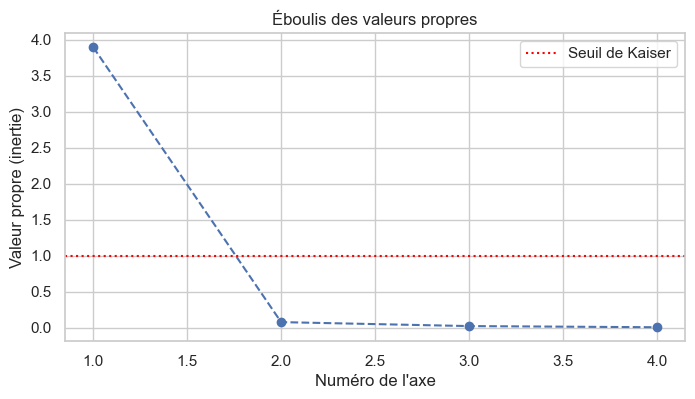

In [18]:
# Cellule 10 : Graphique d'éboulis
plt.figure(figsize=(8, 4))

# Tracer les valeurs propres
# À COMPLÉTER : Créer un graphique ligne avec marqueurs
plt.plot(np.arange(1, 5), valeurs_propres, marker='o', linestyle='--')

# Ajouter la ligne de Kaiser (seuil à 1)
plt.axhline(1, color='red', linestyle=':', label='Seuil de Kaiser')

plt.xlabel("Numéro de l'axe")
plt.ylabel("Valeur propre (inertie)")
plt.title("Éboulis des valeurs propres")
plt.legend()
plt.grid(True)
plt.show()

## Partie 7 : Coordonnées factorielles

In [19]:
# Cellule 11 : Projection des individus
# Calcul des coordonnées sur les axes principaux
# À COMPLÉTER : F = Z × U (où U = vecteurs propres)
F = np.dot(Z, vecteurs_propres)

# Création d'un DataFrame avec les 2 premiers axes
# À COMPLÉTER : Sélectionner les 2 premières colonnes
df_coords = pd.DataFrame(F[:, :2], index=Z.index, columns=['Axe1', 'Axe2'])

print("Coordonnées des étudiants sur les 2 premiers axes :")
display(df_coords)

Coordonnées des étudiants sur les 2 premiers axes :


,Axe1,Axe2
Ahmed,2.321550,0.469574
Fatima,1.677196,0.277100
Omar,-2.195486,-0.216410
Layla,-2.664815,0.238045
Youssef,0.216936,-0.227762
Sara,2.798407,-0.035865
Khaled,-3.099921,0.308607
Nour,1.079620,-0.317901
Mounir,-0.337865,-0.286260
Hoda,0.204379,-0.209128


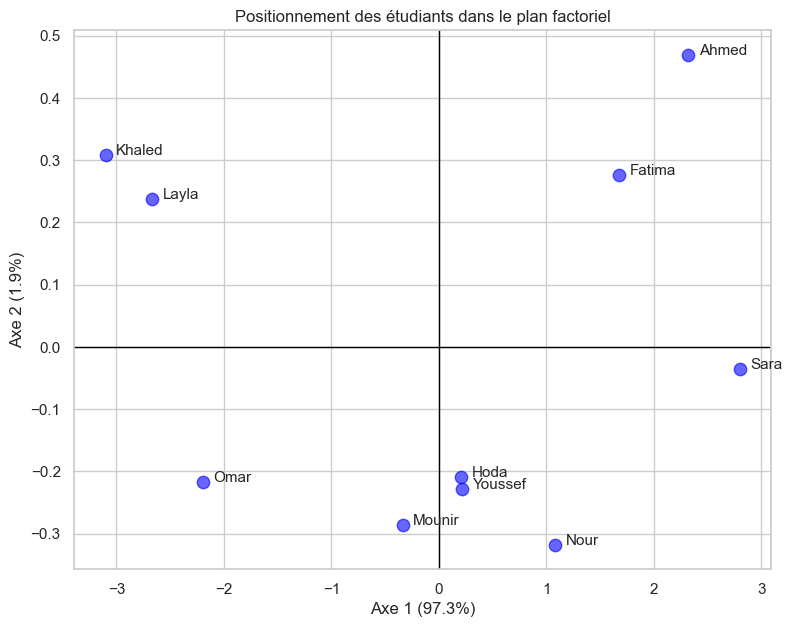

In [38]:
# Cellule 12 : Représentation graphique
plt.figure(figsize=(9, 7))

# Nuage de points
# À COMPLÉTER : Tracer les points avec scatter
plt.scatter(df_coords['Axe1'], df_coords['Axe2'], c='blue', alpha=0.6, s=80)

# Ajouter les noms des étudiants
for i, nom in enumerate(df.index):
    plt.text(df_coords['Axe1'].iloc[i] + 0.1, df_coords['Axe2'].iloc[i], nom, fontsize=11)

# Lignes de repère
plt.axhline(0, color='black', linewidth=1)  # Axe horizontal
plt.axvline(0, color='black', linewidth=1)  # Axe vertical

plt.xlabel(f"Axe 1 ({ratio_inertie[0]*100:.1f}%)")
plt.ylabel(f"Axe 2 ({ratio_inertie[1]*100:.1f}%)")
plt.title("Positionnement des étudiants dans le plan factoriel")
plt.grid(True)
plt.show()

## Partie 8 : Cercle des corrélations

In [ ]:
# Cellule 13 : Coordonnées des variables
# Calcul des coordonnées des matières
# À COMPLÉTER : Coord = vecteur propre × √(valeur propre)
coord_variables = vecteurs_propres * np.sqrt(valeurs_propres)

print("Coordonnées des matières sur le plan 1-2 :")
for i, matiere in enumerate(df.columns):
    print(f"{matiere:10} : ({coord_variables[i, 0]:.3f}, {coord_variables[i, 1]:.3f})")

Coordonnées des matières sur le plan 1-2 :
Maths      : (0.989, 0.119)
Physique   : (0.984, 0.157)
Arabe      : (-0.989, 0.120)
Anglais    : (-0.984, 0.156)


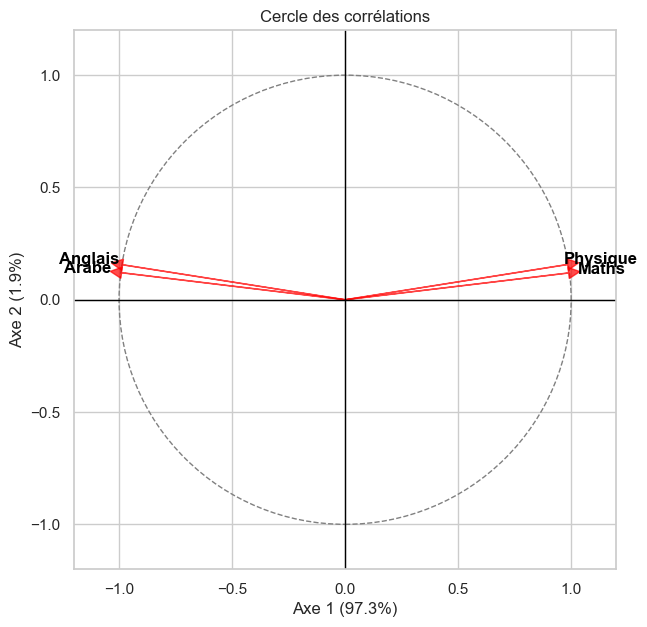

In [33]:
# Cellule 14 : Cercle des corrélations
fig, ax = plt.subplots(figsize=(7, 7))

# Tracer le cercle unité
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_artist(cercle)

# Tracer les flèches pour chaque matière
for i in range(len(df.columns)):
    x, y = coord_variables[i, 0], coord_variables[i, 1]
    plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, fc='red', ec='red', alpha=0.7)
    plt.text(x*1.15, y*1.15, df.columns[i], color='black', 
             ha='center', va='center', fontweight='bold', fontsize=12)

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel(f"Axe 1 ({ratio_inertie[0]*100:.1f}%)")
plt.ylabel(f"Axe 2 ({ratio_inertie[1]*100:.1f}%)")
plt.title("Cercle des corrélations")
plt.grid(True)
plt.show()

## Partie 9 : Contributions des individus

In [34]:
# Cellule 15 : Calcul des contributions
# Contribution à l'axe 1
# À COMPLÉTER : CTR_i = (coordonnée_i)² / (n × valeur_propre)
contrib_axe1 = (df_coords['Axe1'] ** 2) / (len(df) * valeurs_propres[0])

# Création d'un DataFrame
df_contrib = pd.DataFrame({'Contribution Axe 1': contrib_axe1}, 
                          index=df.index)

print("Contributions à la formation de l'axe 1 :")
print("Seuil significatif :", 1/n)
print("\nClassement des contributions :")
display(df_contrib.sort_values('Contribution Axe 1', ascending=False))

Contributions à la formation de l'axe 1 :
Seuil significatif : 0.1

Classement des contributions :


,Contribution Axe 1
Khaled,0.246821
Sara,0.201142
Layla,0.182396
Ahmed,0.138432
Omar,0.123806
Fatima,0.072252
Nour,0.029938
Mounir,0.002932
Youssef,0.001209
Hoda,0.001073


## Partie 10 : Validation avec scikit-learn

In [36]:
# Cellule 16 : ACP automatisée
# Import des modules scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardisation
scaler = StandardScaler()
Z_auto = scaler.fit_transform(df)

# 2. ACP
# À COMPLÉTER : Créer un objet PCA avec 2 composantes
acp = PCA(n_components=2)
coords_auto = acp.fit_transform(Z_auto)

# Comparaison
print("=== COMPARAISON DES RÉSULTATS ===\n")
print("Coordonnées manuelles (Ahmed) :", df_coords.loc['Ahmed'].values)
print("Coordonnées automatiques (Ahmed) :", coords_auto[0])
print("\nValeurs propres (sklearn) :", acp.explained_variance_)
print("Valeurs propres (manuelle) :", valeurs_propres[:2])
print("\n→ Les résultats sont-ils identiques ? Pourquoi ?")

=== COMPARAISON DES RÉSULTATS ===

Coordonnées manuelles (Ahmed) : [2.32154963 0.46957435]
Coordonnées automatiques (Ahmed) : [-2.32154963  0.46957435]

Valeurs propres (sklearn) : [4.32590389 0.08621376]
Valeurs propres (manuelle) : [3.8933135  0.07759238]

→ Les résultats sont-ils identiques ? Pourquoi ?


## Partie 11 : Questions de réflexion

**À répondre dans cette cellule Markdown :**

### Question 1 : Interprétation des axes
- Que représente l'axe 1 ? Justifiez avec le cercle des corrélations.
    - => Axe 1 : 97.3%
- Que représente l'axe 2 ?
    - => Axe 2 : 1.9%
### Question 2 : Profils des étudiants
- Quels sont les 2 étudiants les plus "scientifiques" ?
    - => Fatima,Sara
- Quels sont les 2 étudiants les plus "littéraires" ?
    - => khaled,layla
- Qui a le profil le plus équilibré ?
    - => Hoda

### Question 3 : Qualité de l'analyse
- Le plan 1-2 est-il suffisant pour représenter les données ?
    - => Oui (99.2%)
- Quelles matières sont mal représentées dans ce plan ?
    - => ........

### Question 4 : Contributions
- Quels étudiants contribuent le plus à la formation de l'axe 1 ?
    - => Hoda,Youssef,Mounir
- Pourquoi à votre avis ?
    - => Car leurs points sont equilibres dans tous les matieres.

### Question 5 : Applications
- À quoi pourrait servir cette analyse dans un contexte réel ?
    - => 
- Quelles décisions pourraient être prises à partir de ces résultats ?
    - => 

## Partie 12 : Code bonus (optionnel)

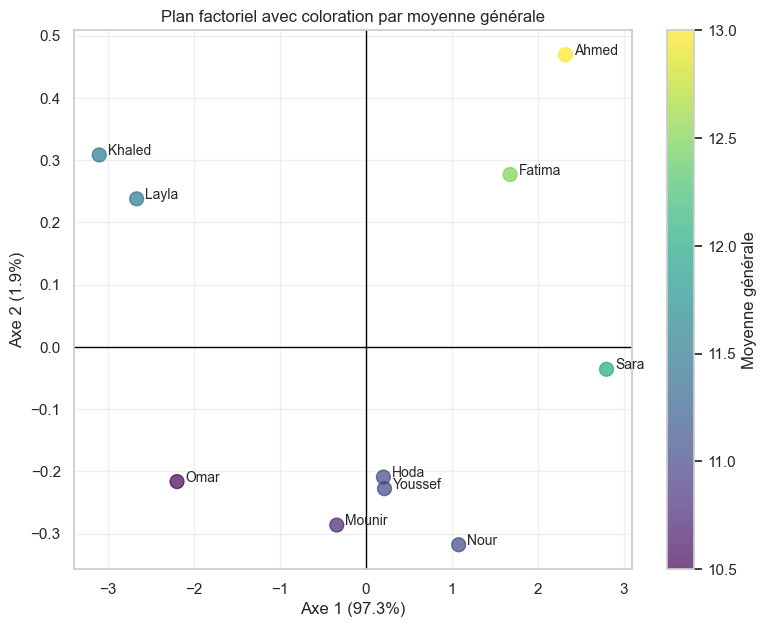

In [53]:
# Cellule 17 : Visualisation avancée
# Essayer de colorer les points selon leur profil


# Exemple 1 : Colorer selon la note moyenne
moyennes_etudiants = df.mean(axis=1)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(df_coords['Axe1'], df_coords['Axe2'], c=moyennes_etudiants, cmap='viridis', s=100, alpha=0.7)

# Ajouter les noms
for i, nom in enumerate(df.index):
    plt.text(df_coords['Axe1'].iloc[i] + 0.1, df_coords['Axe2'].iloc[i], nom, fontsize=10)

plt.colorbar(scatter, label='Moyenne générale')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel(f"Axe 1 ({ratio_inertie[0]*100:.1f}%)")
plt.ylabel(f"Axe 2 ({ratio_inertie[1]*100:.1f}%)")
plt.title("Plan factoriel avec coloration par moyenne générale")
plt.grid(True, alpha=0.3)
plt.show()



## 📊 Formulaire récapitulatif

**Formules importantes à retenir :**

1. **Centrage-réduction** : $Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}$

2. **Matrice de corrélation** : $R = \frac{1}{n} Z^T Z$

3. **Décomposition spectrale** : $R = U \Lambda U^T$

4. **Coordonnées des individus** : $F = ZU$

5. **Coordonnées des variables** : $V = U \sqrt{\Lambda}$

6. **Contribution d'un individu** : $CTR_i^{(k)} = \frac{f_{ik}^2}{n \times \lambda_k}$